<a href="https://colab.research.google.com/github/swagatpatil7/covid19-case-analysis/blob/main/covid_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analytics Project: Infectious Disease Case Analysis
**Company:** HealthGuard Analytics Pvt. Ltd.

**Project Title:** COVID-19 Early Case Trend Analysis & Recovery Insights


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [2]:
proccessed_df = pd.read_csv('/content/patient.csv', low_memory=False)
print('Shape:', proccessed_df.shape)
proccessed_df.head()

Shape: (4212, 14)


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('Data Types:')
print(proccessed_df.dtypes)

Data Types:
id                    int64
sex                  object
birth_year          float64
country              object
region               object
group                object
infection_reason     object
infection_order     float64
infected_by         float64
contact_number      float64
confirmed_date       object
released_date        object
deceased_date        object
state                object
dtype: object


In [4]:
print('Missing Values:')
print(proccessed_df.isnull().sum())

Missing Values:
id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
dtype: int64


## 4. Feature Engineering

In [6]:
# Derive age from birth year
proccessed_df['age'] = 2020 - proccessed_df['birth_year']

# Parse date columns
proccessed_df['confirmed_date'] = pd.to_datetime(proccessed_df['confirmed_date'])
proccessed_df['released_date']  = pd.to_datetime(proccessed_df['released_date'])
proccessed_df['deceased_date']  = pd.to_datetime(proccessed_df['deceased_date'])

# Calculate recovery duration
proccessed_df['recovery_days'] = (proccessed_df['released_date'] - proccessed_df['confirmed_date']).dt.days

print('Age stats:')
print(proccessed_df['age'].describe())
print('\nRecovery days stats:')
print(proccessed_df['recovery_days'].describe())

Age stats:
count    292.000000
mean      46.815068
std       17.336573
min        2.000000
25%       33.000000
50%       48.000000
75%       61.000000
max       83.000000
Name: age, dtype: float64

Recovery days stats:
count    28.000000
mean     15.107143
std       5.626256
min       7.000000
25%       9.750000
50%      16.000000
75%      19.250000
max      24.000000
Name: recovery_days, dtype: float64


## 5. Demographic Analysis
### 5.1 Gender Distribution

/tmp/ipykernel_4550/1947949294.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')


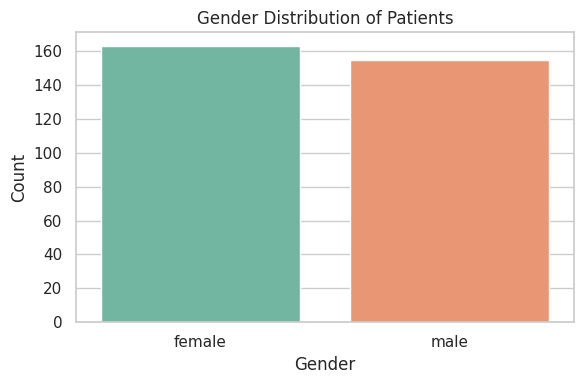

sex
female    163
male      155
Name: count, dtype: int64


In [7]:
gender_counts = proccessed_df['sex'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(gender_counts)

### 5.2 Age Distribution

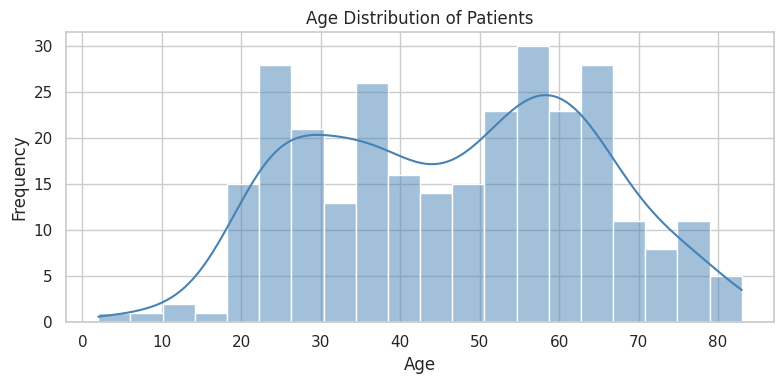

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(proccessed_df['age'].dropna(), bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Case Outcome Distribution

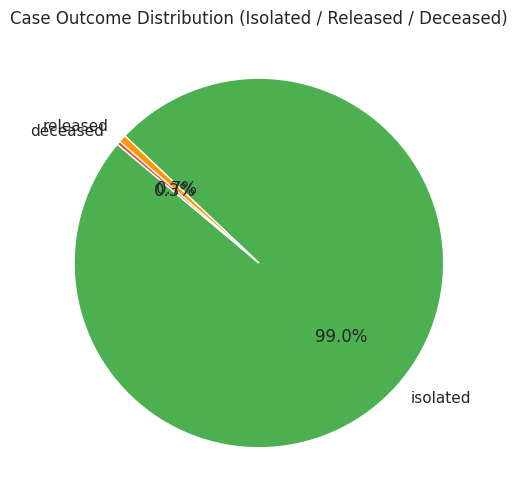

state
isolated    4171
released      28
deceased      13
Name: count, dtype: int64


In [20]:
state_counts = proccessed_df['state'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(state_counts.values, labels=state_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#FF9800', '#F44336'], startangle=140)
plt.title('Case Outcome Distribution (Isolated / Released / Deceased)')
plt.show()

print(state_counts)

## 7. Infection Spread Analysis
### 7.1 Infection Reasons

/tmp/ipykernel_4550/1370853840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='coolwarm')


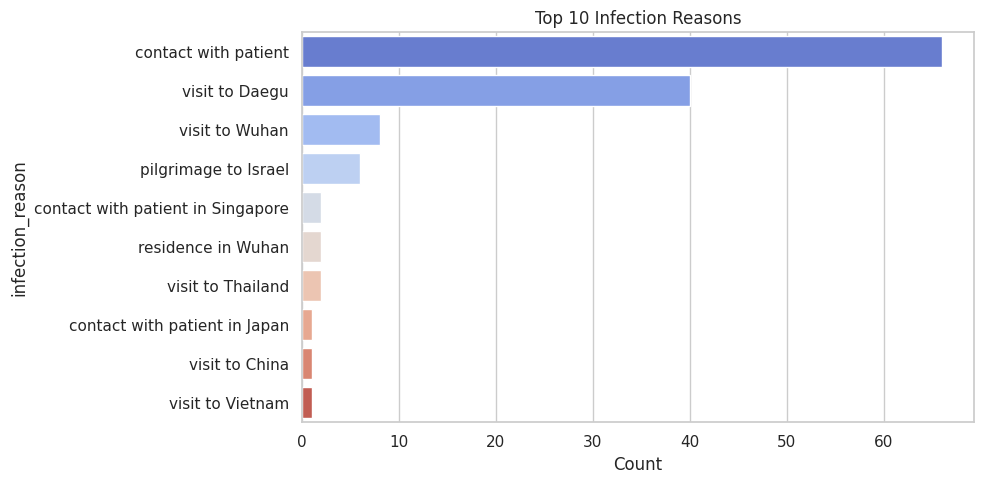

In [10]:
top_reasons = proccessed_df['infection_reason'].value_counts().dropna().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='coolwarm')
plt.title('Top 10 Infection Reasons')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 7.2 Infection Order (Generation of Spread)

/tmp/ipykernel_4550/4162323668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='infection_order', data=proccessed_df, palette='Set1')


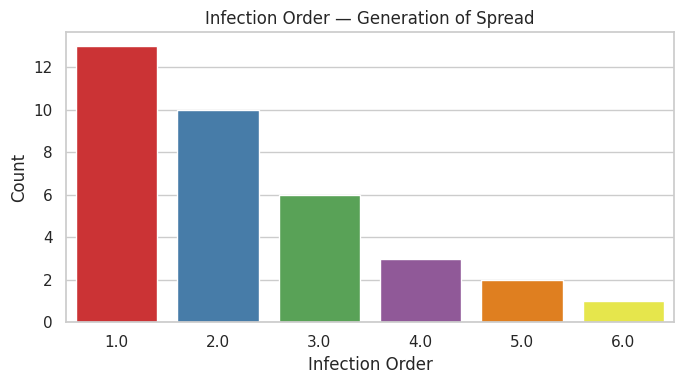

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(x='infection_order', data=proccessed_df, palette='Set1')
plt.title('Infection Order — Generation of Spread')
plt.xlabel('Infection Order')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 8. Regional Analysis
### 8.1 Top Regions by Case Count

/tmp/ipykernel_4550/1969805096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, palette='Blues_r')


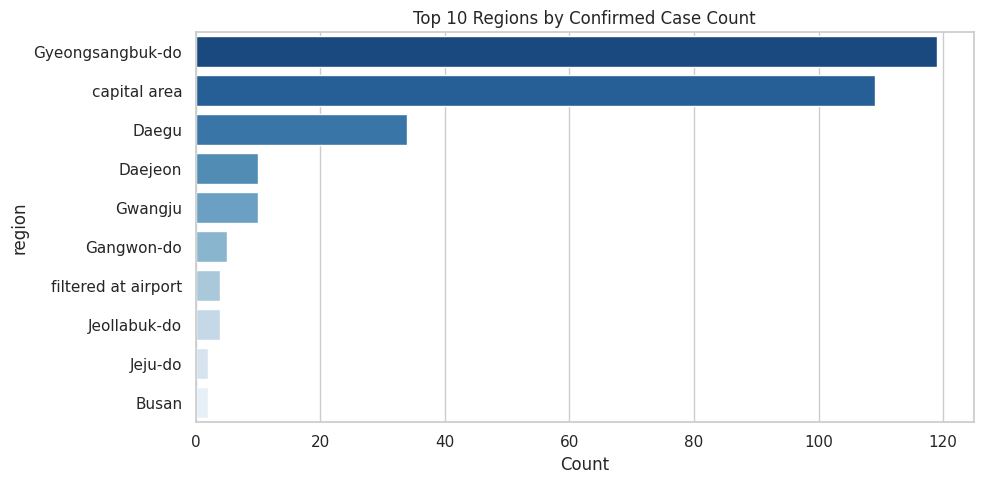

In [12]:
top_regions = proccessed_df['region'].value_counts().dropna().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='Blues_r')
plt.title('Top 10 Regions by Confirmed Case Count')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### 8.2 Confirmed vs Released Cases by Region

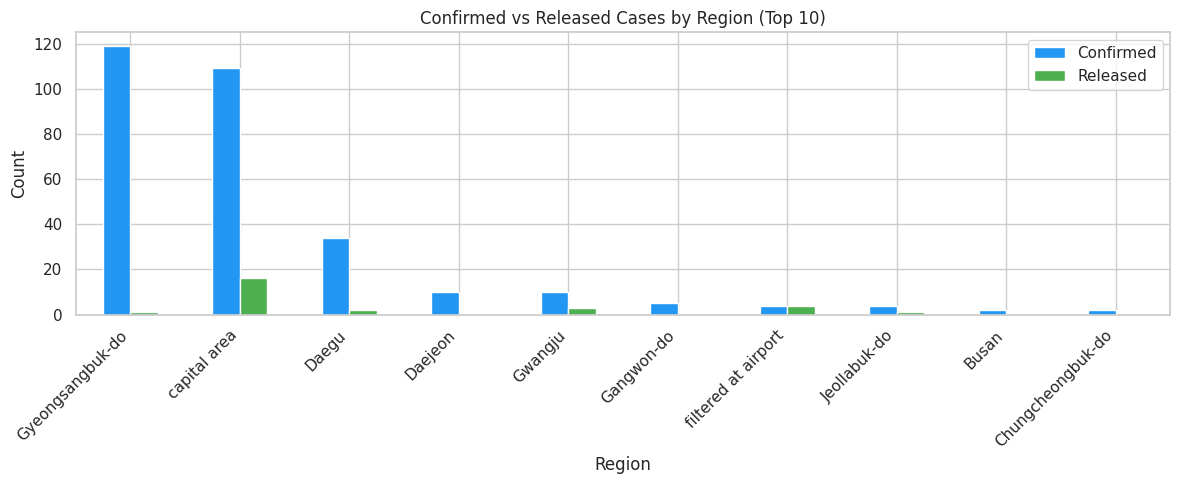

In [13]:
confirmed_by_region = proccessed_df.groupby('region').size().rename('Confirmed')
released_by_region  = proccessed_df[proccessed_df['state'] == 'released'].groupby('region').size().rename('Released')

regional_df = pd.concat([confirmed_by_region, released_by_region], axis=1).fillna(0)
regional_df = regional_df.sort_values('Confirmed', ascending=False).head(10)

regional_df.plot(kind='bar', figsize=(12, 5), color=['#2196F3', '#4CAF50'])
plt.title('Confirmed vs Released Cases by Region (Top 10)')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Recovery Timeline Analysis
### 9.1 Recovery Duration Distribution

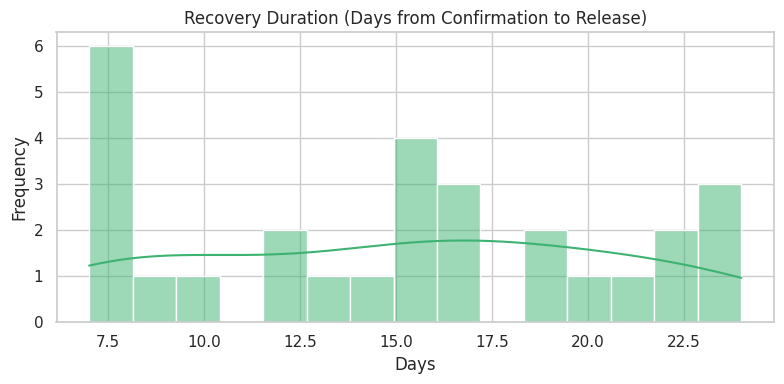

count    28.000000
mean     15.107143
std       5.626256
min       7.000000
25%       9.750000
50%      16.000000
75%      19.250000
max      24.000000
Name: recovery_days, dtype: float64


In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(proccessed_df['recovery_days'].dropna(), bins=15, kde=True, color='mediumseagreen')
plt.title('Recovery Duration (Days from Confirmation to Release)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(proccessed_df['recovery_days'].describe())

### 9.2 Age vs Recovery Duration

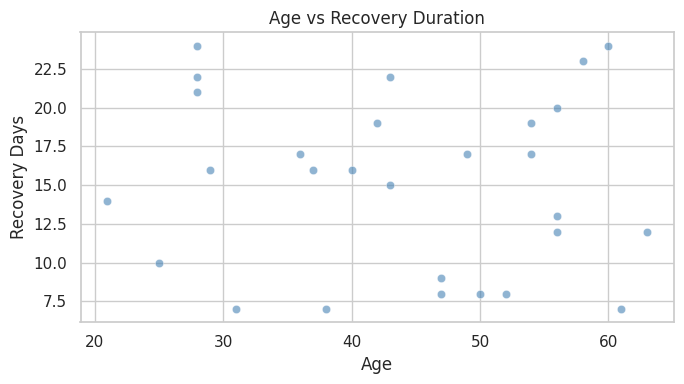

In [22]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='recovery_days', data=proccessed_df, alpha=0.6, color='steelblue')
plt.title('Age vs Recovery Duration')
plt.xlabel('Age')
plt.ylabel('Recovery Days')
plt.tight_layout()
plt.show()

### 9.3 Contact Number vs Recovery Duration

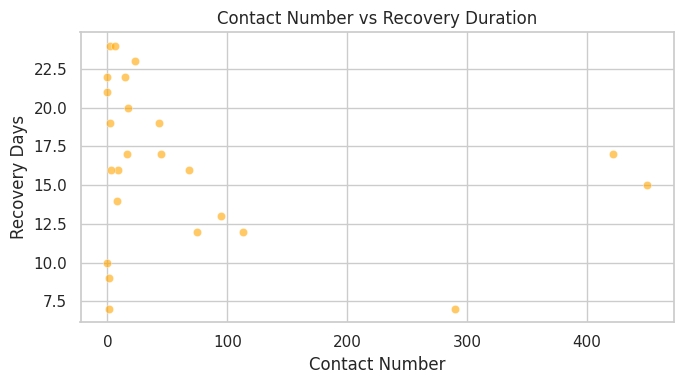

In [16]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='contact_number', y='recovery_days', data=proccessed_df, alpha=0.6, color='orange')
plt.title('Contact Number vs Recovery Duration')
plt.xlabel('Contact Number')
plt.ylabel('Recovery Days')
plt.tight_layout()
plt.show()

## 10. Correlation Analysis

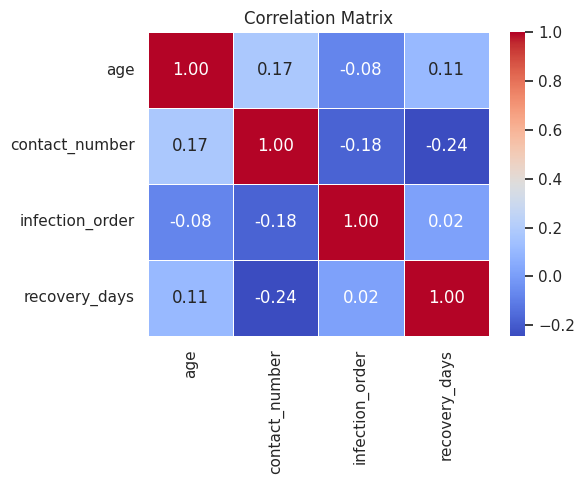

In [17]:
corr_df = proccessed_df[['age', 'contact_number', 'infection_order', 'recovery_days']].dropna()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 11. Linear Regression — Predicting Recovery Days (Optional Extension)

In [18]:
reg_df = proccessed_df[['age', 'contact_number', 'infection_order', 'recovery_days']].dropna()

X = reg_df[['age', 'contact_number', 'infection_order']]
y = reg_df['recovery_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('R² Score :', round(r2_score(y_test, y_pred), 4))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print('Coefficients:', dict(zip(X.columns, model.coef_.round(3))))
print('Intercept:', round(model.intercept_, 3))

R² Score : -0.6577
RMSE     : 3.4
Coefficients: {'age': np.float64(0.079), 'contact_number': np.float64(-0.009), 'infection_order': np.float64(0.021)}
Intercept: 13.095


### 11.1 Residual Plot

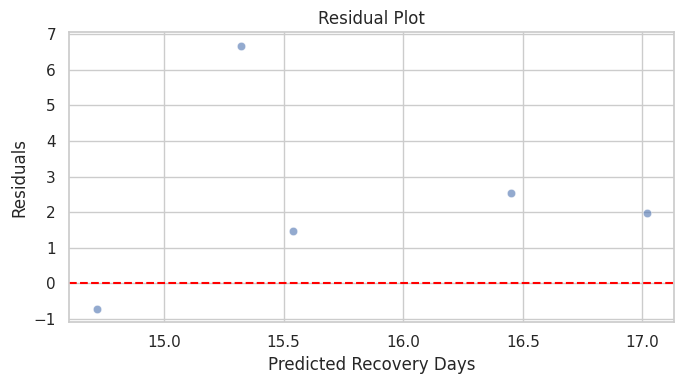

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Recovery Days')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()